In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv("C://Users//utsav//OneDrive//Desktop//Student_Performance.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [4]:
data.sample(3)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
7126,5,70,Yes,8,3,60.0
2391,5,91,Yes,5,5,74.0
9266,5,75,No,8,7,59.0


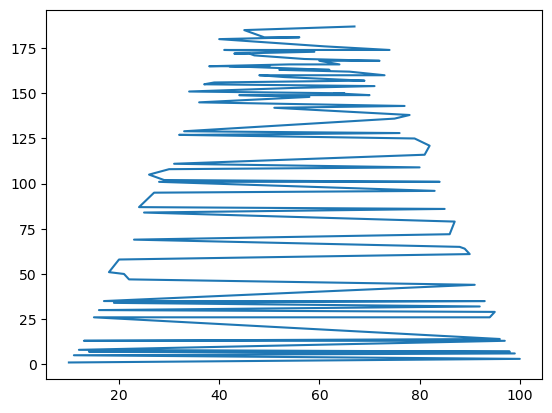

In [6]:
plt.plot(data['Performance Index'].value_counts())

In [8]:
data.shape

(10000, 6)

In [12]:
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [20]:
data[data.duplicated() == True].index

Index([ 915, 1477, 1601, 1786, 2026, 2114, 2338, 2466, 2501, 2576,
       ...
       9563, 9587, 9604, 9620, 9623, 9644, 9940, 9954, 9966, 9985],
      dtype='int64', length=127)

In [23]:
data = data.drop_duplicates()

In [26]:
data.duplicated().unique

<bound method Series.unique of 0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 9873, dtype: bool>

In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
le = LabelEncoder()
data['Extracurricular Activities'] = le.fit_transform(data['Extracurricular Activities'])

C:\Users\utsav\AppData\Local\Temp\ipykernel_32820\1949609026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Extracurricular Activities'] = le.fit_transform(data['Extracurricular Activities'])


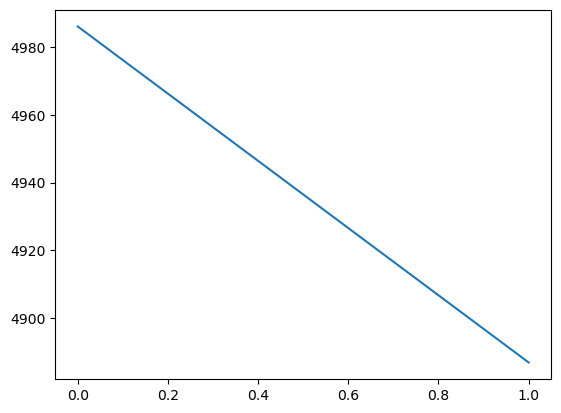

In [33]:
plt.plot(data['Extracurricular Activities'].value_counts())

In [48]:
data.shape

(9873, 6)

In [34]:
data['Extracurricular Activities'].unique()

array([1, 0])

In [35]:
data.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [55]:
X = data.drop('Performance Index', axis = 1)
Y = data['Performance Index']

In [56]:
X.shape
#Y.shape

(9873, 5)

In [57]:
Y.shape

(9873,)

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
from sklearn.preprocessing import StandardScaler

In [60]:
from sklearn.pipeline import Pipeline

In [63]:
from sklearn.linear_model import (LinearRegression , Ridge , Lasso)

In [61]:
x_train , x_test , y_train , y_test = train_test_split(X , Y , test_size = 0.2 , random_state = 42)

In [62]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((7898, 5), (1975, 5), (7898,), (1975,))

In [76]:
scaler = StandardScaler()
model = LinearRegression()

In [81]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [78]:
model.fit(x_train_scaled , y_train)

LinearRegression()

In [82]:
y_pred = model.predict(x_test_scaled)

In [83]:
from sklearn.metrics import r2_score , accuracy_score

In [97]:
r2_score(y_pred , y_test)

0.9882856957337527

In [87]:
alpha = np.linspace(0.1 , 10 , 100)
from sklearn.linear_model import ElasticNet

In [95]:
score_dict = {}
for i in alpha:
    elastic_net_model = ElasticNet(alpha = i)
    elastic_net_model.fit(x_train_scaled , y_train)
    y_predicted = elastic_net_model.predict(x_test_scaled)
    score_dict[i] = r2_score(y_test , y_predicted)

In [94]:
score_dict

{np.float64(0.1): 0.9838936409080227,
 np.float64(0.2): 0.9733829898125331,
 np.float64(0.30000000000000004): 0.9566116155430427,
 np.float64(0.4): 0.9334355928960629,
 np.float64(0.5): 0.9037092470479865,
 np.float64(0.6): 0.8672852029031689,
 np.float64(0.7000000000000001): 0.8240972953382232,
 np.float64(0.8): 0.774029438699238,
 np.float64(0.9): 0.7168498209638008,
 np.float64(1.0): 0.6524051529605696,
 np.float64(1.1): 0.5805401356553166,
 np.float64(1.2000000000000002): 0.501403115340072,
 np.float64(1.3000000000000003): 0.4149520657916802,
 np.float64(1.4000000000000001): 0.3207284505694832,
 np.float64(1.5000000000000002): 0.21857434985001445,
 np.float64(1.6): 0.10832942409444202,
 np.float64(1.7000000000000002): -0.010169098848772373,
 np.float64(1.8000000000000003): -0.13647543625446024,
 np.float64(1.9000000000000001): -0.27126907491086905,
 np.float64(2.0): -0.41476197669998305,
 np.float64(2.1): -0.5671309912194196,
 np.float64(2.2): -0.7285564469867778,
 np.float64(2.300

In [99]:
best_alpha = max(score_dict, key=score_dict.get)
print(f"Best alpha: {best_alpha}, R² score: {score_dict[best_alpha]}")

Best alpha: 0.1, R² score: 0.9856880763372639
